For only the selected features heatmaps
Hierbij is de Scaling apart voor Original Group en Perturbation group. Dus deze kan je niet een op een per perturbation met elkaar vergelijken. Zelf denk ik wel echt dat dat belangrijk is als je daar conclusies uit wilt trekken

Ik denk dat het voordeel hierbij echt is dat je echt puur per perturbation de verschillende levels met elkaar vergelijkt, en niet dat de Original of Wiener ook nog invloed kan hebben 

Hieronder is het Original en Wiener niet met elkaar vergelijken

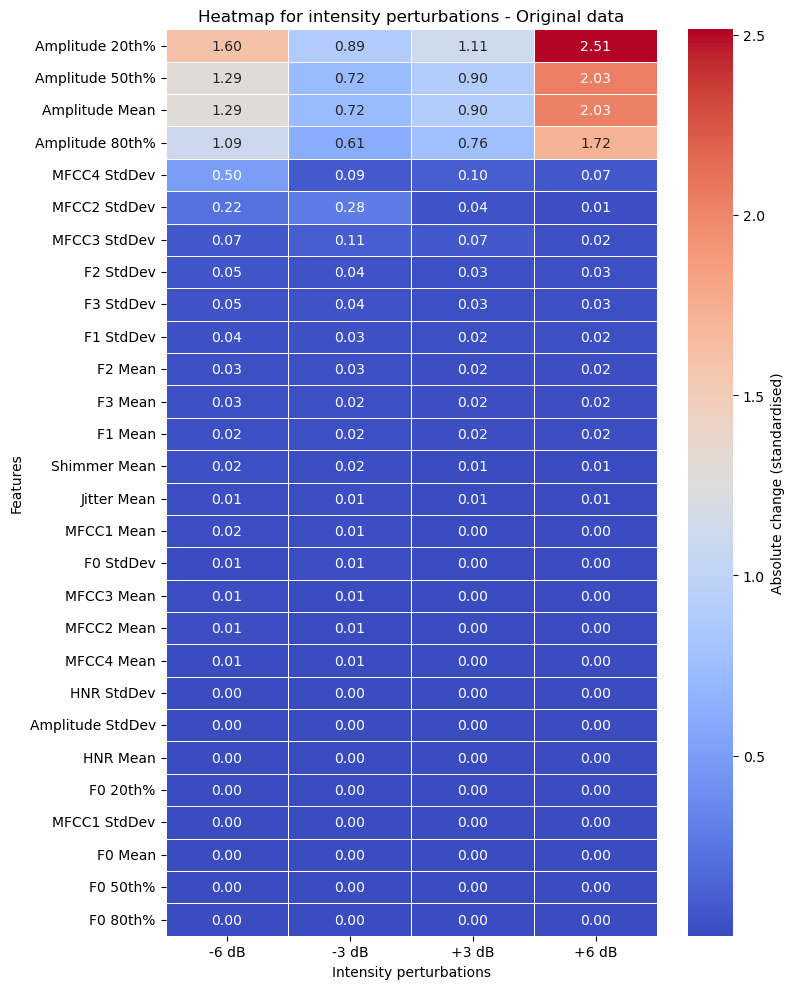

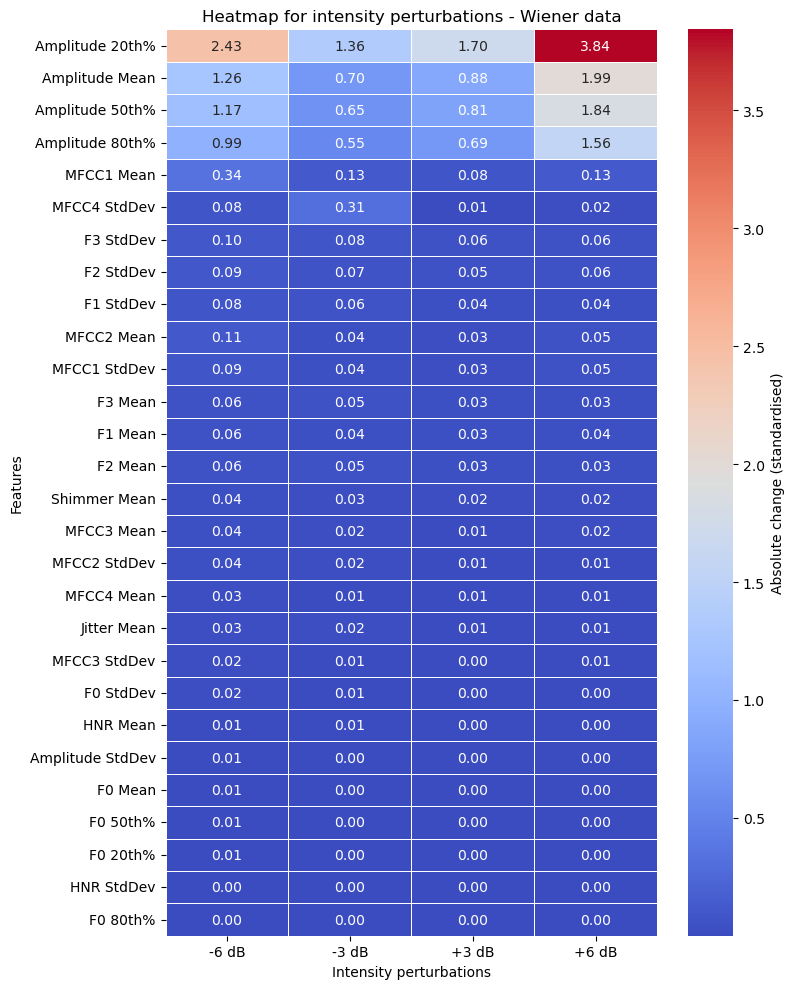

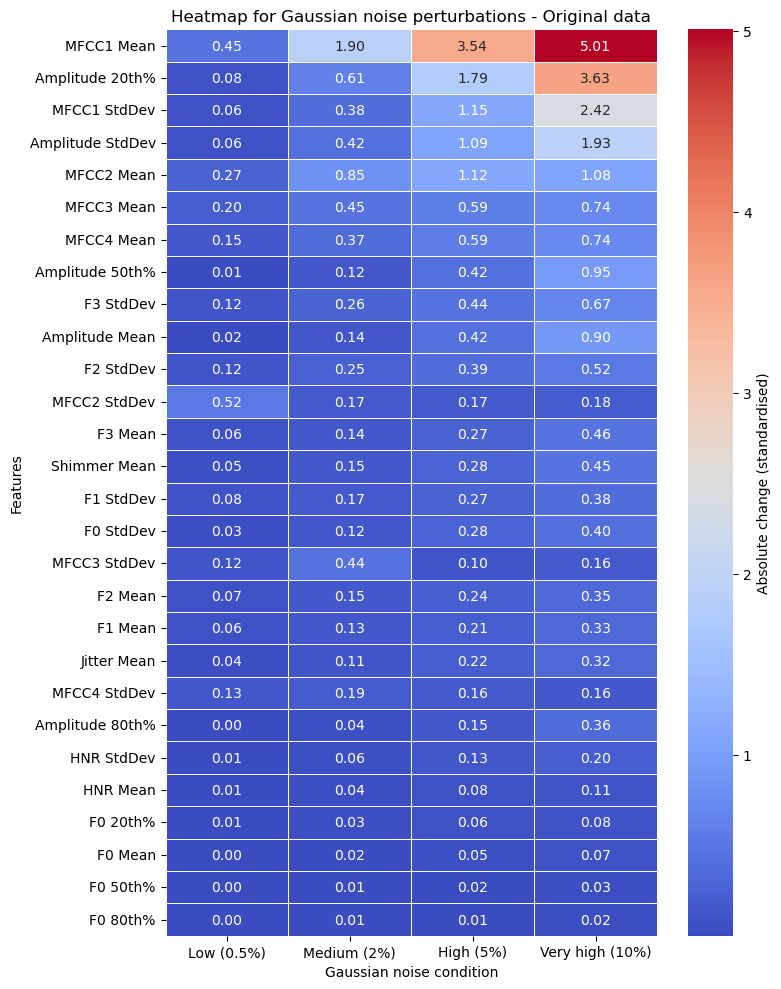

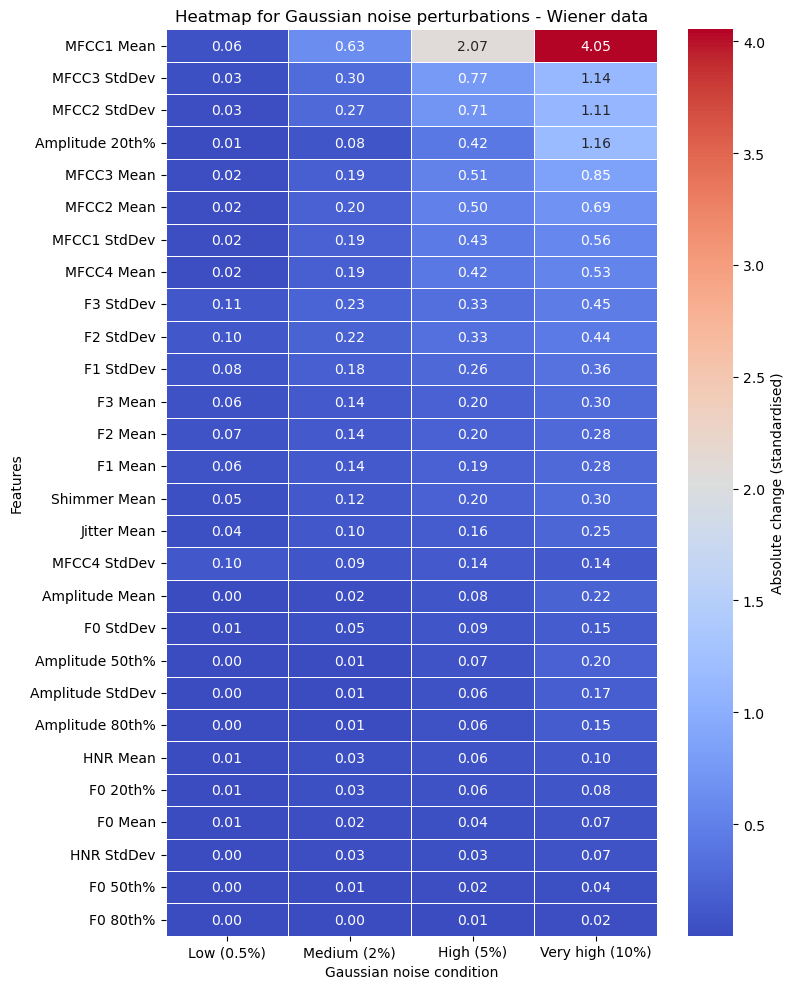

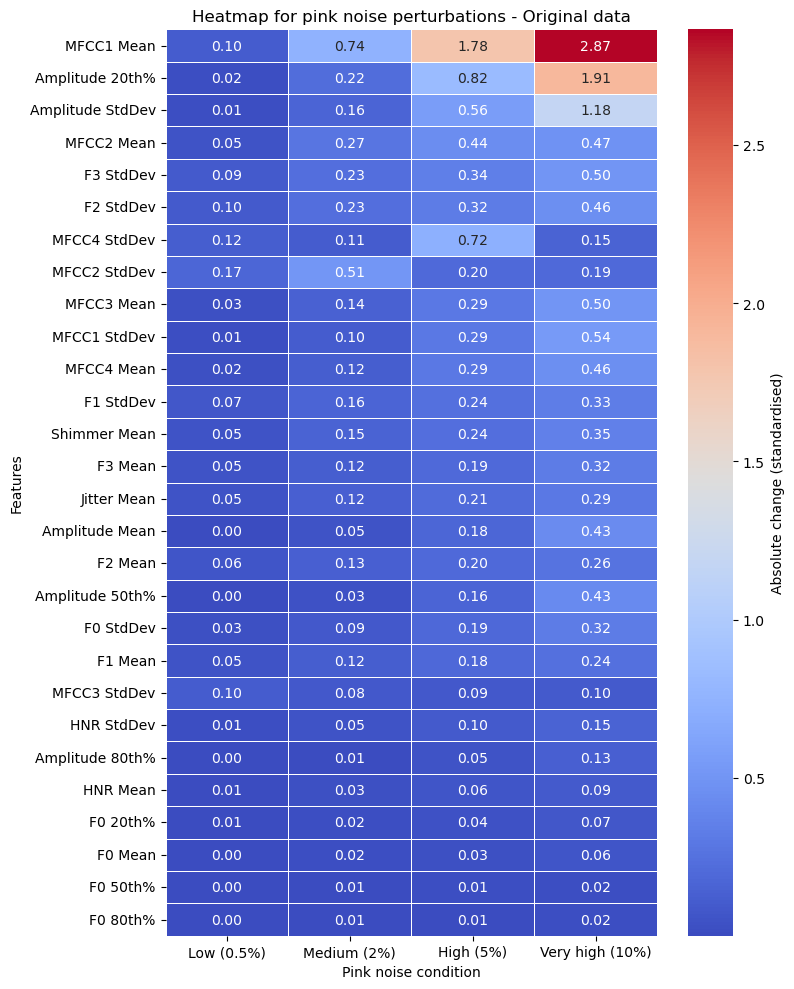

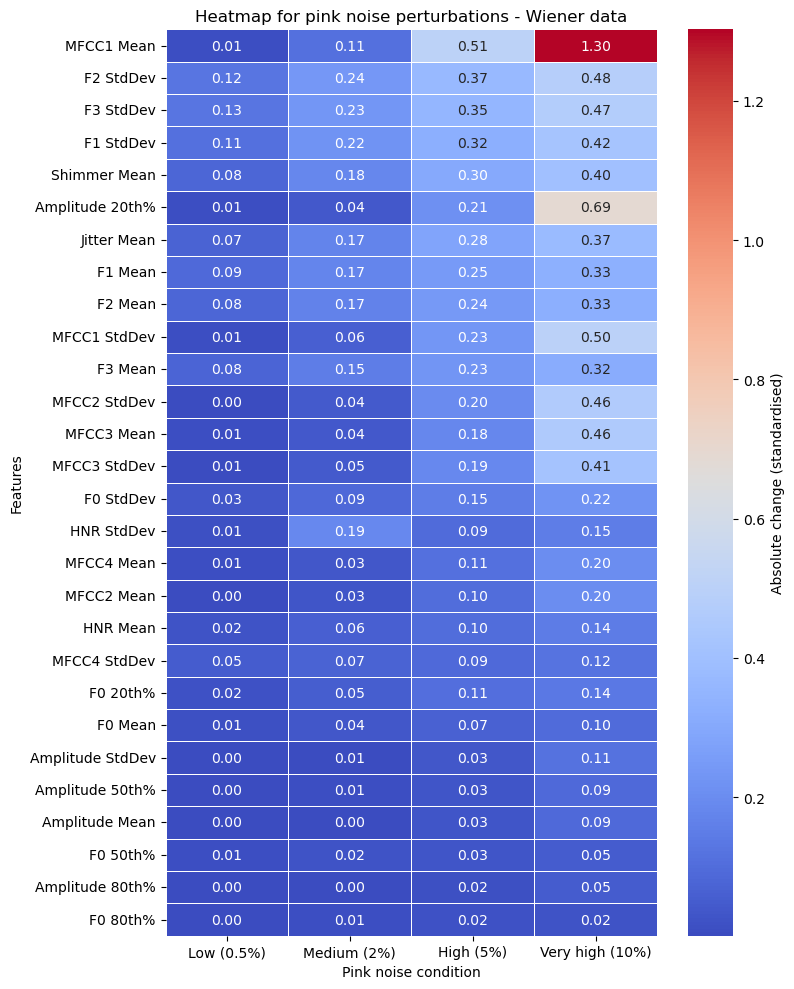

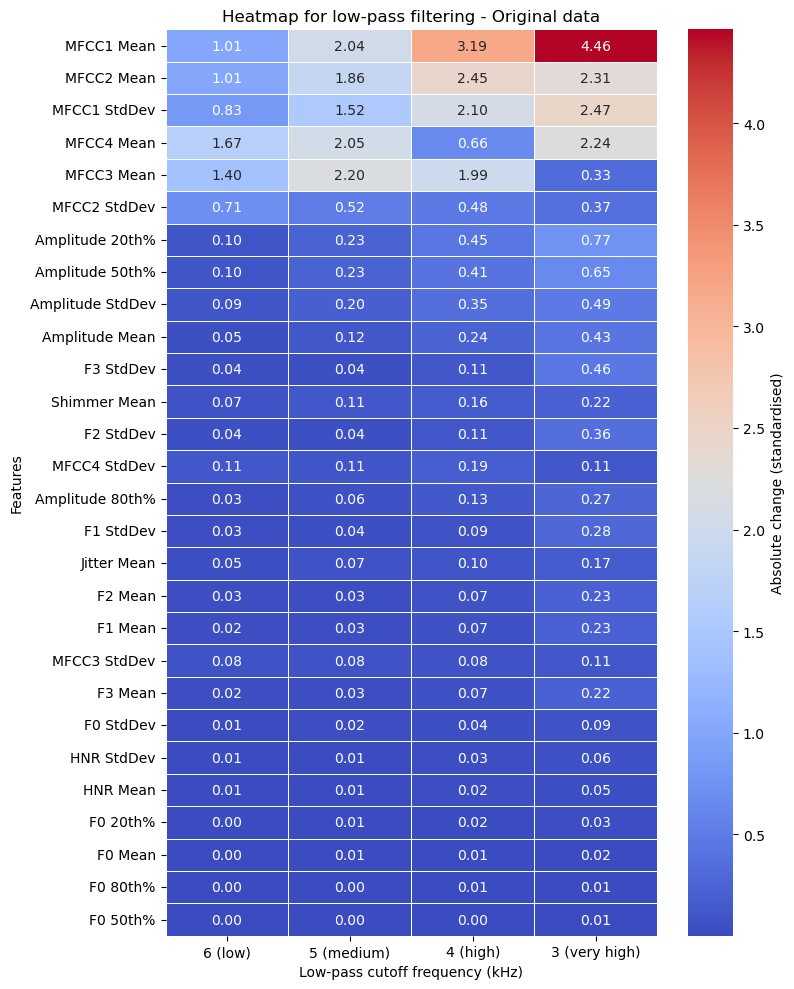

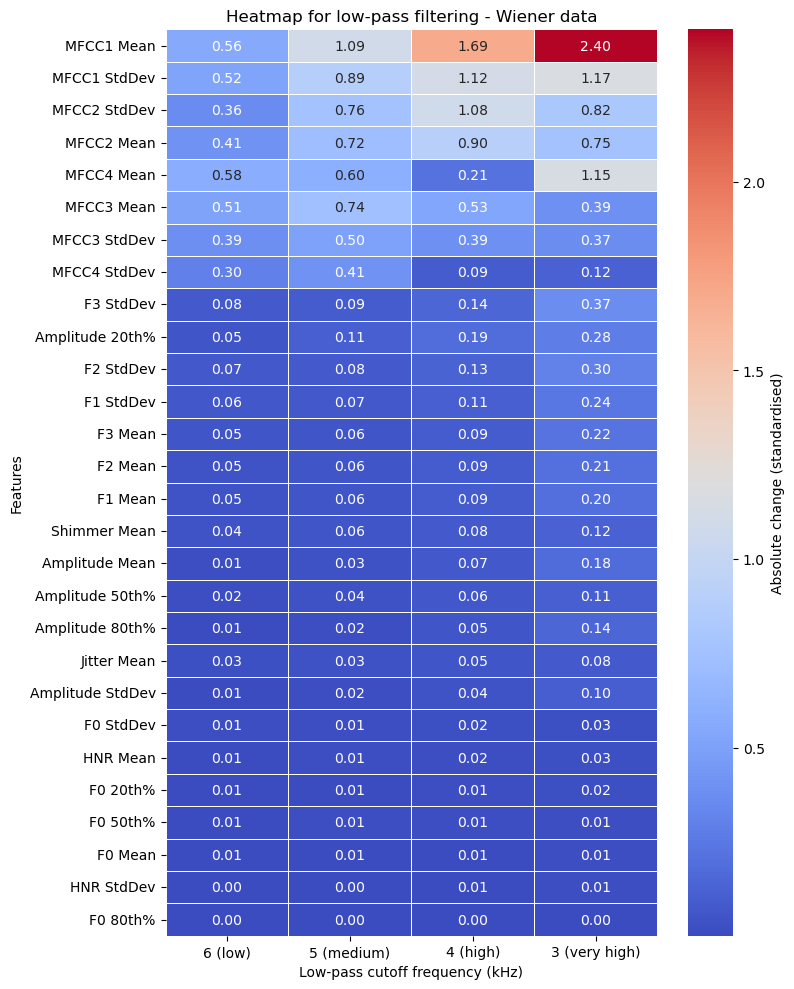

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Paths
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

# Selected features
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# =========================
# Configuratie
# =========================
ROBUSTNESS_CONFIG = {
    "intensity": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "-6 dB": {
                "original": "opensmile_original_intensity_-6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-6dB_pain.csv",
            },
            "-3 dB": {
                "original": "opensmile_original_intensity_-3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_-3dB_pain.csv",
            },
            "+3 dB": {
                "original": "opensmile_original_intensity_3dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_3dB_pain.csv",
            },
            "+6 dB": {
                "original": "opensmile_original_intensity_6dB_pain.csv",
                "wiener": "opensmile_wiener_intensity_6dB_pain.csv",
            },
        },
        "xlabel": "Intensity perturbations",
        "title": "Heatmap for intensity perturbations",
    },
    "gaussian_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_gaussian_low_pain.csv",
                "wiener": "opensmile_wiener_gaussian_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_gaussian_medium_pain.csv",
                "wiener": "opensmile_wiener_gaussian_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_gaussian_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_gaussian_very_high_pain.csv",
                "wiener": "opensmile_wiener_gaussian_very_high_pain.csv",
            },
        },
        "xlabel": "Gaussian noise condition",
        "title": "Heatmap for Gaussian noise perturbations",
    },
    "pink_noise": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "Low (0.5%)": {
                "original": "opensmile_original_pink_low_pain.csv",
                "wiener": "opensmile_wiener_pink_low_pain.csv",
            },
            "Medium (2%)": {
                "original": "opensmile_original_pink_medium_pain.csv",
                "wiener": "opensmile_wiener_pink_medium_pain.csv",
            },
            "High (5%)": {
                "original": "opensmile_original_pink_high_pain.csv",
                "wiener": "opensmile_wiener_pink_high_pain.csv",
            },
            "Very high (10%)": {
                "original": "opensmile_original_pink_very_high_pain.csv",
                "wiener": "opensmile_wiener_pink_very_high_pain.csv",
            },
        },
        "xlabel": "Pink noise condition",
        "title": "Heatmap for pink noise perturbations",
    },
    "lowpass": {
        "original": "opensmile_original_pain.csv",
        "wiener": "opensmile_wiener_pain.csv",
        "conditions": {
            "6 (low)": {
                "original": "opensmile_original_lowpass_low_pain.csv",
                "wiener": "opensmile_wiener_lowpass_low_pain.csv",
            },
            "5 (medium)": {
                "original": "opensmile_original_lowpass_medium_pain.csv",
                "wiener": "opensmile_wiener_lowpass_medium_pain.csv",
            },
            "4 (high)": {
                "original": "opensmile_original_lowpass_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_high_pain.csv",
            },
            "3 (very high)": {
                "original": "opensmile_original_lowpass_very_high_pain.csv",
                "wiener": "opensmile_wiener_lowpass_very_high_pain.csv",
            },
        },
        "xlabel": "Low-pass cutoff frequency (kHz)",
        "title": "Heatmap for low-pass filtering",
    },
}

EXCLUDE_COLS = ["participant_id", "filename", "file_path", "name"]

# =========================
# Functies
# =========================
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    return df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)


def validate_matching_ids(reference_df, comparison_dfs):
    reference_ids = reference_df[["participant_id", "filename"]]

    for name, df in comparison_dfs.items():
        current_ids = df[["participant_id", "filename"]]
        if not reference_ids.equals(current_ids):
            raise ValueError(f"Mismatch in {name}")


def get_selected_feature_cols(df, selected_features_dict):
    missing_features = [col for col in selected_features_dict.values() if col not in df.columns]
    if missing_features:
        raise ValueError(f"Deze selected features ontbreken in de data:\n{missing_features}")
    return list(selected_features_dict.values())


def standardize_against_reference(dfs, feature_cols, reference_key="original"):
    scaler = StandardScaler()
    scaler.fit(dfs[reference_key][feature_cols])

    dfs_std = {}
    for key, df in dfs.items():
        df_std = df.copy()
        df_std[feature_cols] = scaler.transform(df[feature_cols])
        dfs_std[key] = df_std

    return dfs_std


def compute_abs_diff_heatmap_df(dfs_std, feature_cols, condition_order, reference_key="original"):
    original_features = dfs_std[reference_key][feature_cols]
    abs_diff_means = {}

    for condition in condition_order:
        perturbed_features = dfs_std[condition][feature_cols]
        abs_diff = np.abs(perturbed_features - original_features)
        abs_diff_means[condition] = abs_diff.mean(axis=0)

    heatmap_df = pd.DataFrame(abs_diff_means, index=feature_cols)
    heatmap_df["mean_change"] = heatmap_df.mean(axis=1)
    heatmap_df = heatmap_df.sort_values(by="mean_change", ascending=False)
    heatmap_df = heatmap_df.drop(columns=["mean_change"])

    return heatmap_df


def rename_heatmap_index(heatmap_df, selected_features_dict):
    reverse_mapping = {v: k for k, v in selected_features_dict.items()}
    heatmap_df = heatmap_df.copy()
    heatmap_df.index = [reverse_mapping.get(idx, idx) for idx in heatmap_df.index]
    return heatmap_df


def plot_heatmap(
    heatmap_df,
    title,
    xlabel,
    ylabel="Features",
    figsize=(8, 10)
):
    plt.figure(figsize=figsize)
    sns.heatmap(
        heatmap_df,
        cmap="coolwarm",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Absolute change (standardised)"},
        annot=True,
        fmt=".2f"
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def run_robustness_evaluation_selected_features(
    base_path,
    config,
    data_type,
    selected_features_dict,
    save_csv=False
):
    """
    data_type = 'original' of 'wiener'
    """
    files = {
        "original": base_path / config[data_type]
    }

    for condition_name, paths in config["conditions"].items():
        files[condition_name] = base_path / paths[data_type]

    dfs = {name: load_and_sort_csv(path) for name, path in files.items()}

    validate_matching_ids(
        reference_df=dfs["original"],
        comparison_dfs={k: v for k, v in dfs.items() if k != "original"}
    )

    feature_cols = get_selected_feature_cols(dfs["original"], selected_features_dict)
    dfs_std = standardize_against_reference(dfs, feature_cols, reference_key="original")

    condition_order = list(config["conditions"].keys())
    heatmap_df = compute_abs_diff_heatmap_df(
        dfs_std=dfs_std,
        feature_cols=feature_cols,
        condition_order=condition_order,
        reference_key="original"
    )

    heatmap_df = rename_heatmap_index(heatmap_df, selected_features_dict)

    if save_csv:
        output_name = f"robustness_selected_features_{data_type}_{config['title'].lower().replace(' ', '_')}.csv"
        heatmap_df.to_csv(base_path / output_name)

    plot_heatmap(
        heatmap_df=heatmap_df,
        title=f"{config['title']} - {data_type.capitalize()} data",
        xlabel=config["xlabel"]
    )

    return heatmap_df


# =========================
# Alles runnen
# =========================
results_selected = {}

for perturbation_name, config in ROBUSTNESS_CONFIG.items():
    results_selected[(perturbation_name, "original")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="original",
        selected_features_dict=selected_features,
        save_csv=False
    )

    results_selected[(perturbation_name, "wiener")] = run_robustness_evaluation_selected_features(
        base_path=BASE_PATH,
        config=config,
        data_type="wiener",
        selected_features_dict=selected_features,
        save_csv=False
    )